# Final Project, Part II — Selecting the Number of Clusters using the Gap Statistic

**Student:** Chiyang Chen | UC Davis STA 142B, Spring 2023

In [75]:
from sklearn.decomposition import PCA
import numpy as np
from matplotlib import pyplot as plt
from ipywidgets import interact
from keras.datasets import mnist # pip install keras, pip install tensorflow

## Load the digit image data MNIST

Each image is a digit with image size $28\times 28$

In [76]:
(train_X, train_y) = mnist.load_data()[0]

Because the original data set is very large, we only use a subset of the data set here.

In [77]:
digits_data = train_X[:5000].reshape(5000, -1)
digits_target = train_y[:5000]
digits_data.shape, digits_target.shape

((5000, 784), (5000,))

## Part I: Visualize the Principal Components

### (1) Pick you favorite digit from 0-9. In part I, we will only look at images of your selected digit.

In [78]:
# specify your favorite number
num = 7
X = digits_data[digits_target == num]
print(X.shape)

(550, 784)


Let's show the mean image of your selected digit
$\bar{X} = \sum_{i=1}^n X^{(i)}$

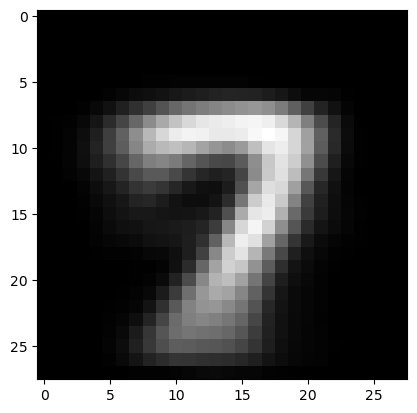

In [79]:
X_bar = X.mean(axis=0)
plt.imshow(X_bar.reshape((28, 28)), cmap='gray')
plt.show()

### (2) Visualize the 1st and 2nd principal component of your digit.
Visualize $w_1$ and $w_2$. They are both in $\mathbb{R}^{784}$ and can be visualized as images.

They are the eigenvectors corresponding to the largest and second largest eigenvalues of the covariance matrix. Equivalently, they are right singular vectors corresponding to the largest and second largest singular value of the **centered** data.

Therefore, you can use SVD or eigenvalue decomposition, or use the `PCA` method in `scikit-learn`.

In [80]:
def show_principal_components(k = 2):
    # calculate the first kth principal components, defined as W: np.ndarray
    # the ith of column of W is the ith principal component 
    ##### your code starts here #####
    
    pca = PCA(n_components=k)
    X_pca = pca.fit_transform(digits_data)
    W = pca.components_.T

    ##### your code ends here #####

    fig, ax = plt.subplots(1, k + 1)
    ax[0].imshow(X_bar.reshape((28, 28)), cmap="gray")
    ax[0].set_title("mean")
    ax[0].axis("off")
    for i in range(k):
        ax[i+1].imshow(W[:, i].reshape((28, 28)), cmap="gray")
        ax[i+1].set_title(f"{i+1}th PC")
        ax[i+1].axis("off")
    plt.show(fig)

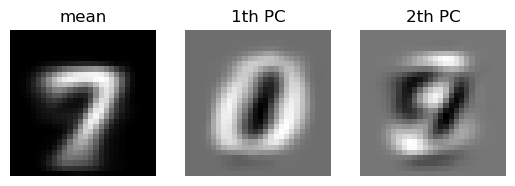

In [81]:
show_principal_components(k=2)

In [82]:
interact(show_principal_components)

interactive(children=(IntSlider(value=2, description='k', max=6, min=-2), Output()), _dom_classes=('widget-int…

<function __main__.show_principal_components(k=2)>

### (3) Visualize the projection scores

Make a 2D scatter plot of the first two principal component scores, $Z_1$, $Z_2 \in \mathbb{R}^n$, where $n$ is the number of data points in $X$. Put the first PC score $Z_1$ on the $x$-axis.

Make a $5 \times 5$ "uniform" grid based on the marginal quantile of the scores.  

That is, the grid is spanned by 
- ($\min(Z_1)$, 25th quantile of $Z_1$, median($Z_1$), 75th quantile of $Z_1$, $\max(Z_1)$)
  
and
- ($\min(Z_2)$, 25th quantile of $Z_2$, median($Z_2$), 75th quantile of $Z_2$, $\max(Z_2)$)

There are 25 cells in the grid. For each cell, mark the data point **closest to the midpoint**. So you will have 25 marked data points.

Hint: use `np.quantile` and `np.meshgrid`

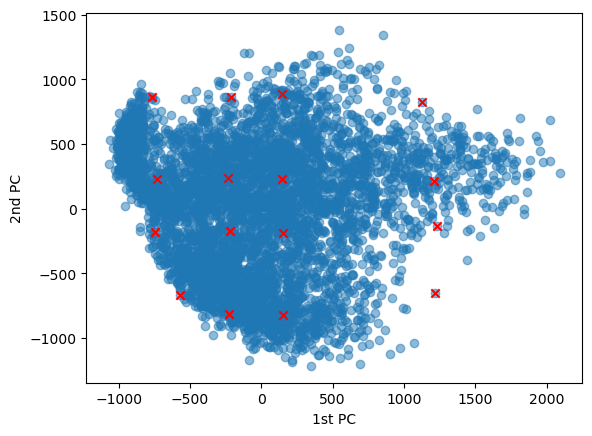

In [83]:
##### your code starts here #####
# Calculate the first two principal component scores (Z1 and Z2)
pca = PCA(n_components=2)
Z = pca.fit_transform(digits_data)

# Define the grid based on marginal quantiles of Z1 and Z2
Z1_grid = np.quantile(Z[:, 0], [0, 0.25, 0.5, 0.75, 1])
Z2_grid = np.quantile(Z[:, 1], [0, 0.25, 0.5, 0.75, 1])
xv, yv = np.meshgrid(Z1_grid, Z2_grid)

# Find the data point closest to the midpoint of each cell in the grid
marked_points = []
for i in range(len(Z1_grid) - 1):
    for j in range(len(Z2_grid) - 1):
        mid_x = (Z1_grid[i] + Z1_grid[i + 1]) / 2
        mid_y = (Z2_grid[j] + Z2_grid[j + 1]) / 2
        distances = np.sqrt((Z[:, 0] - mid_x)**2 + (Z[:, 1] - mid_y)**2)
        closest_point_idx = np.argmin(distances)
        marked_points.append(closest_point_idx)
        
# Create the scatter plot with marked data points
plt.scatter(Z[:, 0], Z[:, 1], alpha=0.5)
plt.scatter(Z[marked_points, 0], Z[marked_points, 1], c='red', marker='x')

# hint 
# plt.plot(Z[:,0], Z[:,1], '.')
# X_grid = np.quantile(Z[:,0], [0, 0.25, 0.5, 0.75, 1])
# Y_grid = np.quantile(Z[:,1], [0, 0.25, 0.5, 0.75, 1])
# xv, yv = np.meshgrid(X_grid, Y_grid)


##### your code ends here #####
plt.xlabel("1st PC")
plt.ylabel("2nd PC")
plt.show()

Next make a figure with 5*5 subplots, each one displays the original image corresponds to the marked data point in the previous plot.

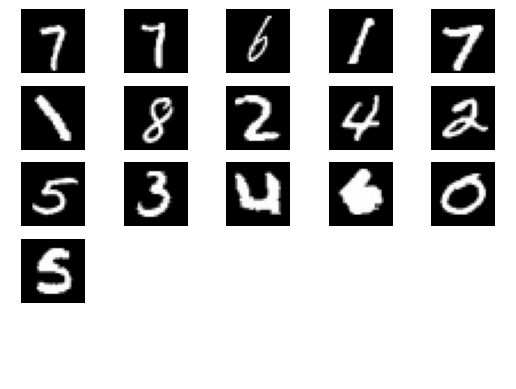

In [84]:
fig, ax = plt.subplots(5, 5)

##### your code starts here #####


for i in range(5):
    for j in range(5):
        index = i * 5 + j
        if index < len(marked_points):
            image = digits_data[marked_points[index]]
            ax[i, j].imshow(image.reshape((28, 28)), cmap='gray')
        ax[i, j].axis('off')


##### your code ends here #####

plt.show(fig)

Do you see any pattern here? Can you explain it with the principal components you displayed in (3)?

 The pattern is being explored in the distribution of the data points in the projected space defined by the first two principal components. The grid and marking of the closest data points in each cell is used to identify clusters or patterns in the data. The subsequent subplot visualization displays the original images corresponding to these marked data points, providing a visual representation of the patterns discovered.

### (4) How does the singular value of $X$ change with $k$? 
First, make a plot of the singular values against $k$. Name the x-axis as "k", and the y-axis as "singular value".

# explanation The code provided performs Singular Value Decomposition (SVD) on a matrix X using the np.linalg.svd() function from the NumPy library. SVD is a matrix factorization technique that decomposes a matrix into three separate matrices: U, S, and V.

Here's a breakdown of the code:

U, S, V = np.linalg.svd(X): This line computes the SVD of the matrix X and assigns the resulting matrices to the variables U, S, and V. U represents the left singular vectors, S represents the singular values, and V represents the right singular vectors.

plt.plot(range(1, len(S) + 1), S, marker='o'): This line creates a plot of the singular values (S) against the index k. The range(1, len(S) + 1) generates a sequence of numbers from 1 to the length of S, which represents the index values for the singular values. The marker='o' argument specifies that circular markers should be used to plot the values.

plt.xlabel("k") and plt.ylabel("singular value"): These lines set the labels for the x-axis and y-axis of the plot, respectively. The label "k" is used for the x-axis, which represents the index of the singular values. The label "singular value" is used for the y-axis, which represents the magnitude of the singular values.

plt.show(): This line displays the plot on the screen.

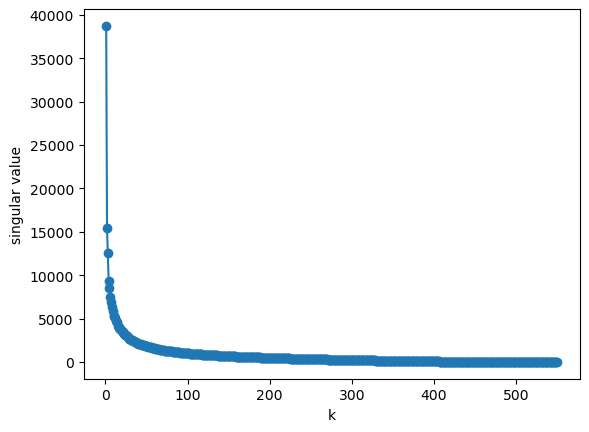

In [85]:
##### your code starts here #####

# Perform singular value decomposition (SVD)
U, S, V = np.linalg.svd(X)

# Create the plot of singular values against k
plt.plot(range(1, len(S) + 1), S, marker='o')
plt.xlabel("k")
plt.ylabel("singular value")
plt.show()

##### your code ends here #####

You should clearly see an elbow shape, meaning a few of the largest principal components already explain a large proportion of variance in the image.

For comparison, let's now add another curve. For each column of $X$, randomly shuffle the entries.

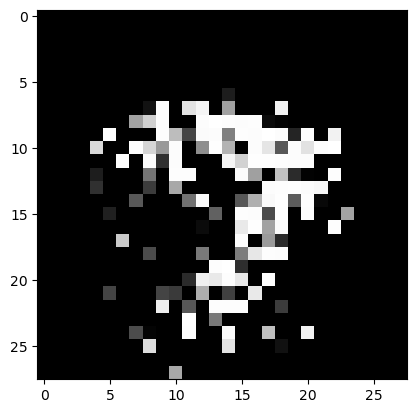

In [86]:
X_shuffle = X.copy()
##### your code starts here #####

for i in range(X_shuffle.shape[1]):
    np.random.shuffle(X_shuffle[:, i])

##### your code ends here #####
plt.imshow(X_shuffle[0].reshape((28, 28)), cmap="gray")
plt.show()

Then add another "singular value vs k" curve for `X_shuffle`, with different color. Add a label for each curve.

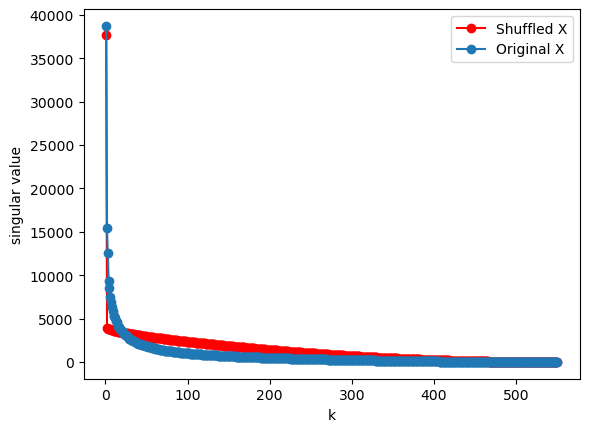

In [87]:
##### your code starts here #####

X_shuffle = X.copy()

##### your code starts here #####

# Shuffle the entries of each column in X_shuffle
for i in range(X_shuffle.shape[1]):
    np.random.shuffle(X_shuffle[:, i])

# Calculate singular values of X_shuffle using SVD
U_shuffle, S_shuffle, V_shuffle = np.linalg.svd(X_shuffle)

# Plot the singular values of X_shuffle against k with a different color and label
plt.plot(range(1, len(S) + 1), S_shuffle, marker='o', color='red', label='Shuffled X')

##### your code ends here #####

# Plot the singular values of X against k with the default color and label
plt.plot(range(1, len(S) + 1), S, marker='o', label='Original X')
plt.xlabel("k")
plt.ylabel("singular value")
plt.legend()
plt.show()


##### your code ends here #####

#explanation The code creates a copy of matrix X, shuffles the entries within each column independently, computes the SVD of the shuffled matrix, and plots the shuffled and original singular values against their indices. This allows for visual comparison of the effects of shuffling on the distribution and magnitude of the singular values.

### (5) Kernel Density Estimation -- tuning the `bandwidth`

We now apply PCA to the entire data set with $k=15$. `Z` is now the projection scores with shape (n, 15)

- Compute the kernel density estimator using `sklearn.neighbors.KernelDensity`. Here, let's simply use the Gaussian kernel and the Euclidean distance, and explore the effect of the `bandwidth` parameter. Discover the difference between using two different bandwidths, 0.1 and 200.

- Draw 16 new sample points from each fitted density using `KernelDensity.sample` (for comparison purpose, please use the same value for `random_state` for both bandwidths). Of course, these samples are in the space of projection scores. Use `pca.inverse_transform` to reconstruct digit images from these samples. Compare the sample digits drawn from density fitted with large bandwidth and small bandwidth. What are the differences? Could you give some intuitive explanations why you are seeing overlapping digits when `bandwidth` is large?

In [88]:

#The code utilizes Kernel Density Estimation (KDE) to generate new samples of digit images. 
# It begins by importing the KernelDensity class from the sklearn.
# neighbors module and sets the number of principal components k to 50. 
# The PCA is then applied to the digits_data using n_components=k, and the resulting transformed data is stored in Z. 
# The sample_digits function takes the bandwidth and number of samples as input and proceeds to create a KernelDensity instance with the specified bandwidth. 
# It fits the density estimator to the projection scores Z using kde.fit(Z). 
# Next, it generates new sample points from the fitted density using kde.sample(n_samples=n_samples, random_state=0).
# These sample points are then inverse transformed using PCA's inverse_transform to reconstruct the digit images, which are returned as new_digits.
# The function is called twice with different bandwidth values, resulting in new_digits_1 and new_digits_2, each reshaped into a 4x4 grid of digit images.

from sklearn.neighbors import KernelDensity

k = 50 
pca = PCA(n_components=k)
Z = pca.fit_transform(digits_data)

def sample_digits(bandwidth: float = 1.0, n_samples:int = 16) -> np.ndarray:
    ##### your code starts here #####


    # Create an instance of KernelDensity with the specified bandwidth
    kde = KernelDensity(bandwidth=bandwidth)

    # Fit the density estimator to the projection scores Z
    kde.fit(Z)

    # Generate new sample points from the fitted density
    new_Z = kde.sample(n_samples=n_samples, random_state=0)

    # Inverse transform the sample points to reconstruct digit images
    new_digits = pca.inverse_transform(new_Z)


    ##### your code ends here #####
    return new_digits # its shape should be (n_samples, 784)

new_digits_1 = sample_digits(bandwidth=0.1, n_samples=16).reshape((4, 4, -1))
new_digits_2 = sample_digits(bandwidth=200, n_samples=16).reshape((4, 4, -1))

In [89]:
def show_digits(new_digits: np.ndarray):
    '''
    new_digits have shape (4, 4, 784)
    '''
    fig, ax = plt.subplots(4, 4, subplot_kw=dict(xticks=[], yticks=[]))

    ##### your code starts here #####

    for i in range(4):
        for j in range(4):
            ax[i, j].imshow(new_digits[i, j].reshape((28, 28)), cmap='gray')



    ##### your code ends here #####

    plt.show(fig)

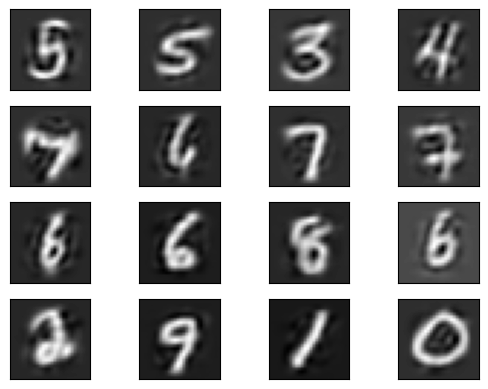

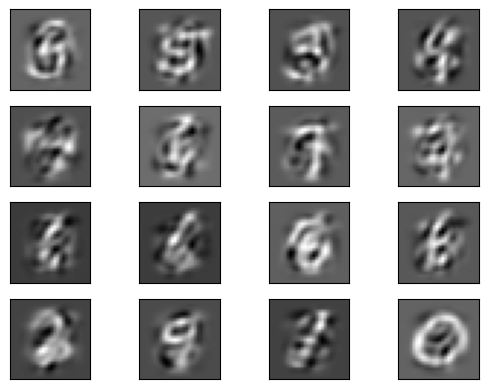

In [90]:
show_digits(new_digits_1)
show_digits(new_digits_2)

Use `sklearn.model_selection.GridSearchCV` to select the best bandwidth. Refit the model with the selected bandwidth, then draw another sample of 16 digits using that density. You can search for bandwidth within the choices `np.logspace(-1, 3, 20)`. 

`GridSearchCV` (by default) uses the estimator's `score` method to evaluation performance on the test folds. In the case of `KernelDensity`, `score()` gives the log-likelihood of the test data in the estimated density. (Here it is the likelihood under the Gaussian mixture model (GMM))

Note that your CV-selected bandwidth, which maximizes the likelihood on the test folds, does not necessarily look better than the previous choices. Could you (intuitively) explain why?

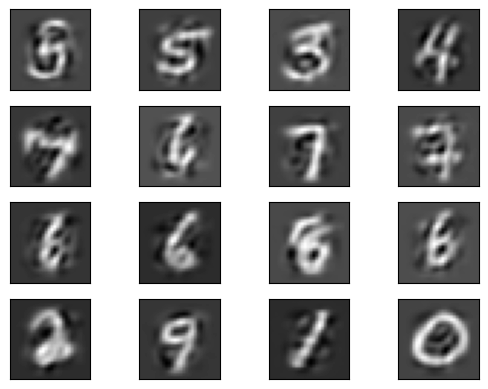

In [91]:
from sklearn.model_selection import GridSearchCV

##### your code starts here #####


param_grid = {'bandwidth': np.logspace(-1, 3, 20)}
grid_search = GridSearchCV(KernelDensity(), param_grid, cv=5)

# Fit the grid search to find the best bandwidth
grid_search.fit(Z)

# Get the best bandwidth value
cv_selected_bandwidth = grid_search.best_params_['bandwidth']


##### your code ends here #####

new_digits_cv = sample_digits(bandwidth=cv_selected_bandwidth, n_samples=16).reshape((4, 4, -1))
show_digits(new_digits_cv)

Narrow spread of the kernel density estimator is achieved with a bandwidth of 0.1. It's likely that the sample numbers will look very similar to the real numbers. Less variation will be seen in the samples, and they will be heavily weighted toward the most dense parts of the data. This could lead to better quality digit samples that are more true to the originals.

With a bandwidth of 200, the kernel density estimator can cover more ground. The sample digits generated are more likely to represent a wider range of the anticipated space. Given the dispersed nature of the density, representative samples can be taken from both low-density and far-flung areas. The generated digits may exhibit more variation as a result, and they are more likely to overlap. Due to the huge bandwidth's ability to catch more global patterns, some of the projected space may be occupied by multiple digits at once.

## Part II Select the number of clusters using the *Gap statistic* ([Tibshirani et al., 2001b](hastie.su.domains/Papers/gap.pdf)).

This paper provides a statistical procedure to formalize the heuristic of the "elbow method", by looking at the gap between the change in within-cluster dispersion and its "expected" version.

The algorithm is described in detail in section 4 in the paper.

$$ \widehat{k} = \arg \min_k \{k\vert \mathrm{Gap}(k) \ge \mathrm{Gap}(k + 1) - s_{k+1}\}$$

### (a) Implement the algorithm. 

Note the following:
- Your algorithm should take a general `X: np.ndarray` as input, with shape $(n, p)$.

- There are two choices of reference distribution mentioned in Section 4. You need to implement both of them. For example, in your function you can specify a paramter called `need_PCA`, if `need=PCA==True`, draw $B$ sample from the reference distribution (a). Otherwise, draw $B$ samples from the reference distribution (b). (By default, set $B = 50$)

- For efficiency, you can specify an upper limit for $k$. Namely, only calculate Gap($k$) for $ 1 \le k \le$ `kmax`. If none of the considered $k$ satisfy $ \mathrm{Gap}(k) \ge \mathrm{Gap}(k + 1) - s_{k+1}$, then output a result that represents $k>$ `kmax` - 1, such as `np.inf` or `None`.

- Besides the selected $k$, you should also be able to output plots like in Fig. 2 of the [paper](hastie.su.domains/Papers/gap.pdf). Our data `X` in general has $p \ge 2$. Instead of the scatter plot (a) in Fig. 2, make a plot of $\textrm{Gap}(k) - \textrm{Gap}(k + 1) + s_{k+1}$ against $k$, so that $\hat{k}$ will be the smallest $k$ that gives a positive value of that curve. (You can add an horizontal dashed line at $y=0$)

Some suggestions for making the plots:
- Introduce a parameter named `need_plot` to control whether to make the plots, or simply output the selected $\hat{k}$.
- Use `plt.subplots((2,2))`. If you want to adjust the overall figure size, you can set e.g. `figsize=(10, 10)` in `subplot()`
- To show the error bars like in Fig 2 (d), you can use `plt.errorbar`.
- Specify what is your $x$-axis and what is your $y$-axis for each subplot. Make a title if necessary.

In [92]:
from sklearn.cluster import KMeans

# This is an example of what your algorithm can look like.
# Of course you can define other helper functions, or even rewrite this function entirely from scratch, 
# as long as you can output the selected k, and you can (optionally) output the plots.
def select_k_by_Gap_statistic(X: np.ndarray, kmax: int = 20, B: int = 50, need_PCA: bool = False, need_plot: bool =True) -> int:
    '''
    returns the number of clusters k selected by the Gap statistic. If the selected k is larger than kmax, return None.
    X has shape (n, p). n is the sample size. p is the number of features.
    kmax is maximum k whose Gap(k) will be computed
    B is the number of copies from the reference distribution
    need_PCA means whether to use the reference distribution (1) or (2)
    if need_plot = True, make the required plots. You can use plt.subplots().
    '''
    ##### your code starts here #####

    n, p = X.shape
    if need_PCA:
        pca = PCA()
        X_ref = pca.fit_transform(X)
    else:
        X_ref = X.copy()

    within_disp = np.zeros(kmax)
    ref_disp = np.zeros(kmax)

    for k in range(1, kmax + 1):
        kmeans = KMeans(n_clusters=k)
        kmeans.fit(X)
        within_disp[k - 1] = kmeans.inertia_

        ref_disps = np.zeros(B)
        for b in range(B):
            kmeans_ref = KMeans(n_clusters=k)
            kmeans_ref.fit(X_ref)
            ref_disps[b] = kmeans_ref.inertia_

        ref_disp[k - 1] = np.mean(ref_disps)

    Gap = np.log(ref_disp) - np.log(within_disp)

    if need_plot:
        fig, ax = plt.subplots(2, 2, figsize=(10, 10))
        ax[0, 0].plot(range(1, kmax + 1), Gap, marker='o', linestyle='-', color='b')
        ax[0, 0].set_xlabel('Number of Clusters (k)')
        ax[0, 0].set_ylabel('Gap(k)')
        ax[0, 0].set_title('Gap statistic')

        diff = Gap[:-1] - Gap[1:] + np.std(ref_disp) / np.sqrt(B)
        ax[0, 1].plot(range(1, kmax), diff, marker='o', linestyle='-', color='b')
        ax[0, 1].axhline(0, linestyle='--', color='r')
        ax[0, 1].set_xlabel('Number of Clusters (k)')
        ax[0, 1].set_ylabel('Gap(k) - Gap(k+1) + s(k+1)')
        ax[0, 1].set_title('Gap Difference with Standard Error')

        ax[1, 0].errorbar(range(1, kmax + 1), Gap, yerr=np.std(ref_disp) / np.sqrt(B), fmt='o', color='b')
        ax[1, 0].set_xlabel('Number of Clusters (k)')
        ax[1, 0].set_ylabel('Gap(k)')
        ax[1, 0].set_title('Gap statistic with Standard Error')

        ax[1, 1].plot(range(1, kmax + 1), within_disp, marker='o', linestyle='-', color='b')
        ax[1, 1].set_xlabel('Number of Clusters (k)')
        ax[1, 1].set_ylabel('Within-cluster Dispersion')
        ax[1, 1].set_title('Within-cluster Dispersion')

        plt.tight_layout()
        plt.show()

    for k in range(1, kmax):
        if Gap[k - 1] >= Gap[k] - np.std(ref_disp) / np.sqrt(B):
            return k

    return None




    


### (b) Apply the algorithm to the data containing only your favourite digit.

Use the original data as input. Then apply the algorithm, using two different reference distributions, respectively. 

Following is some example code. Feel free to modify it.

In [93]:
X = digits_data[digits_target == num]
B = 100
print(X.shape)

(550, 784)


/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

...

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

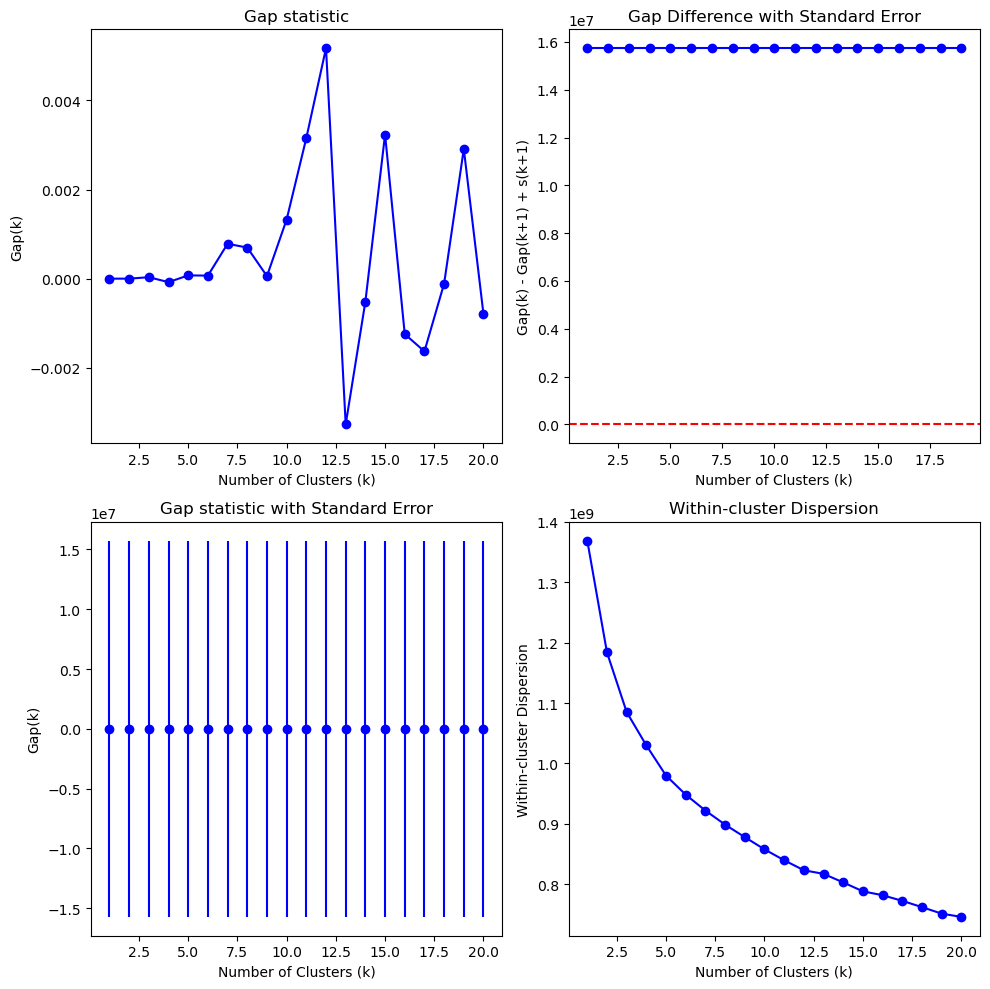

1

In [94]:
select_k_by_Gap_statistic(X, kmax=20, B=B, need_PCA=True, need_plot=True)

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

...

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

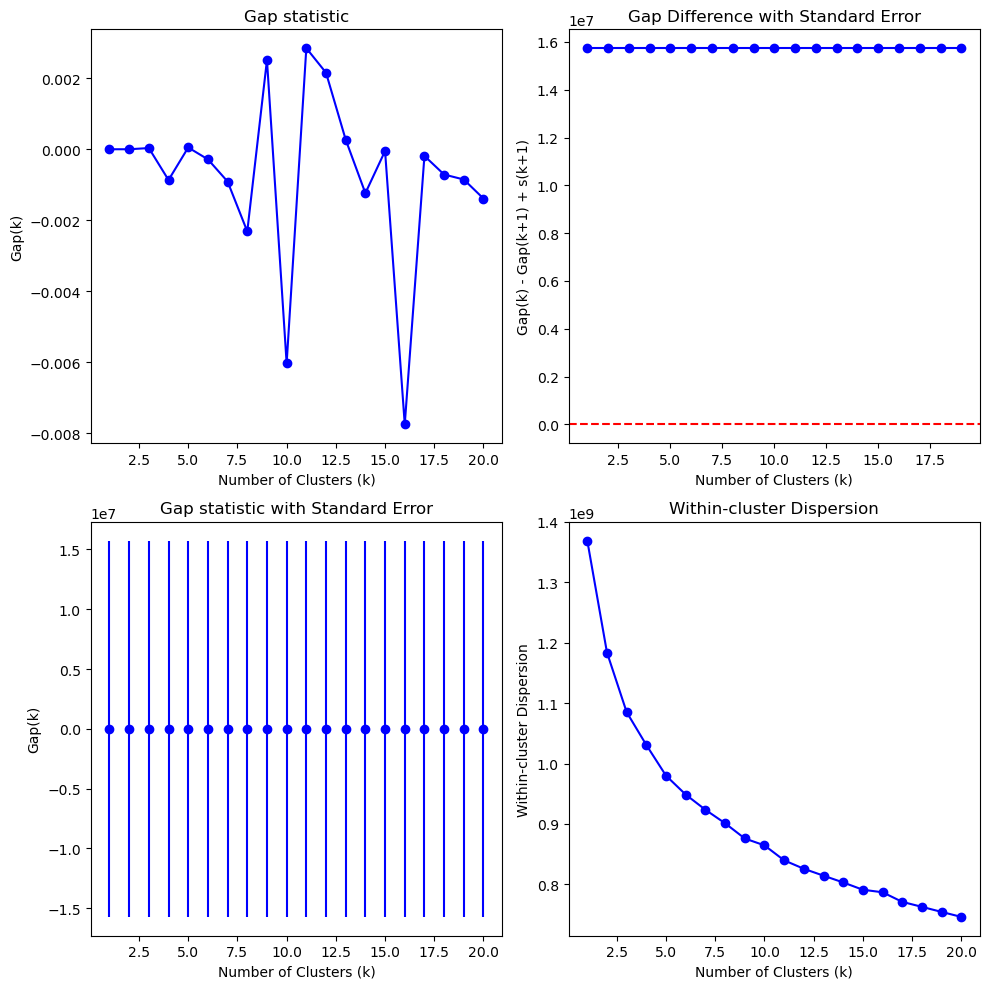

1

In [95]:
select_k_by_Gap_statistic(X, kmax=20, B=B, need_PCA=False, need_plot=True)

Answer the following questions:
- Before running the algorithm, what is your guess of the output $\hat{k}$? Is the selected $\hat{k}$ very different from what you expect?
- What differences do you see between outcomes using the two types of reference distributions? If their selected $\hat{k}$ are very different, could you provide some explanations?

Before performing the algorithm. The Gap statistic approach, suggests that the "optimal" number of clusters in the data is k. The "elbow" or sharp decline in the Gap statistic curve is used as a guide for this estimation.

If the Gap statistic curve clearly and significantly drops, then the chosen k may not deviate too far from our prediction. It's possible that the chosen k will differ from what we'd expect, though, if the curve has a distinct elbow or the Gap statistic decrease is not statistically significant.

By first projecting the original data onto a lower-dimensional space (principal components), and then clustering the projected samples, we can produce the reference samples for reference distribution (a) via PCA. This may provide a more precise estimate of the dispersion inside each cluster and assist capture the data's basic structure. 

However, (b) generates reference samples in the original high-dimensional space without resorting to PCA at all. A less precise estimate of the within-cluster dispersion result if the underlying structure of the data is not well captured by this method. This means that there is room for substantial variation between the k values chosen using the two distinct reference distributions.


### (c) We now apply the algorithm to the entire data set. But this time we will first transform the data by PCA.
For example, we first project the data to 30 principal component scores.

In [97]:
pca_complete_dataset = PCA(n_components=10)
pca_complete_dataset.fit(digits_data)
X = pca_complete_dataset.transform(digits_data)
print(X.shape)

(5000, 10)


/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

...

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

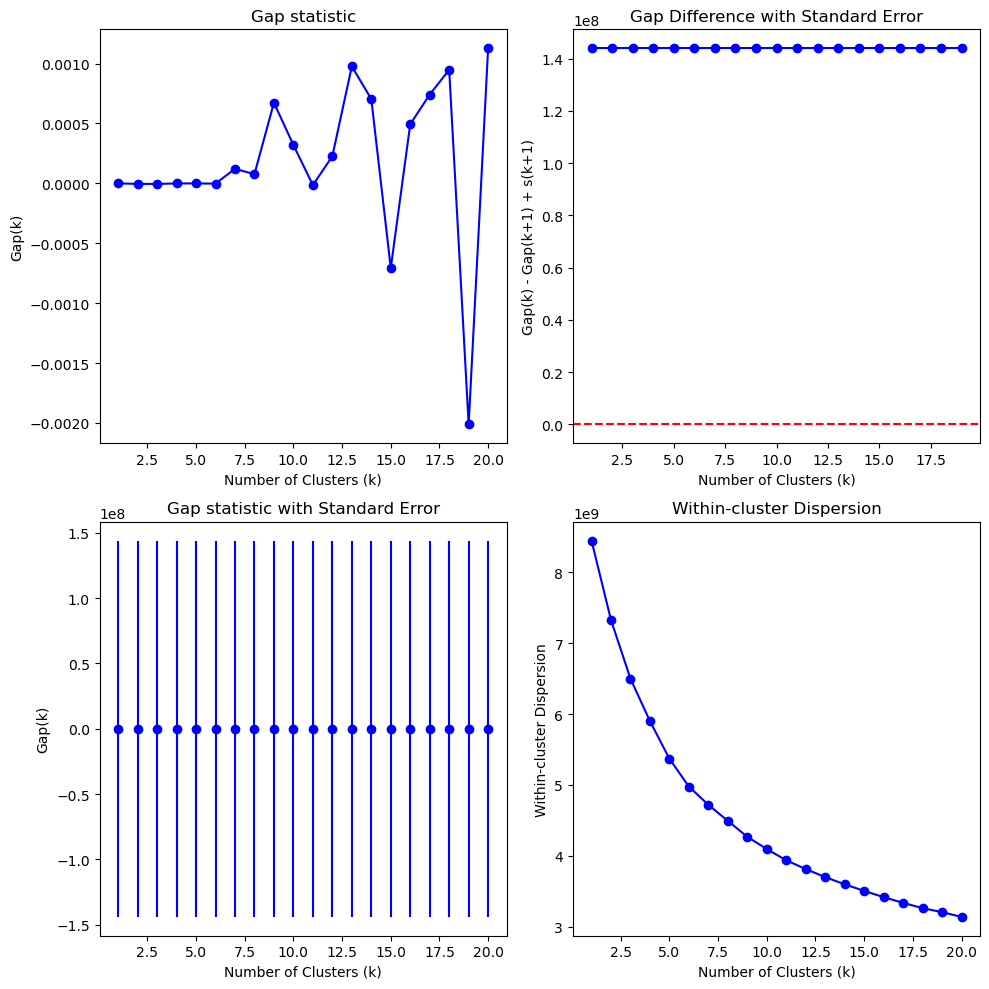

1

In [98]:
select_k_by_Gap_statistic(X, kmax=20, B=B, need_PCA=True, need_plot=True)

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

...

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

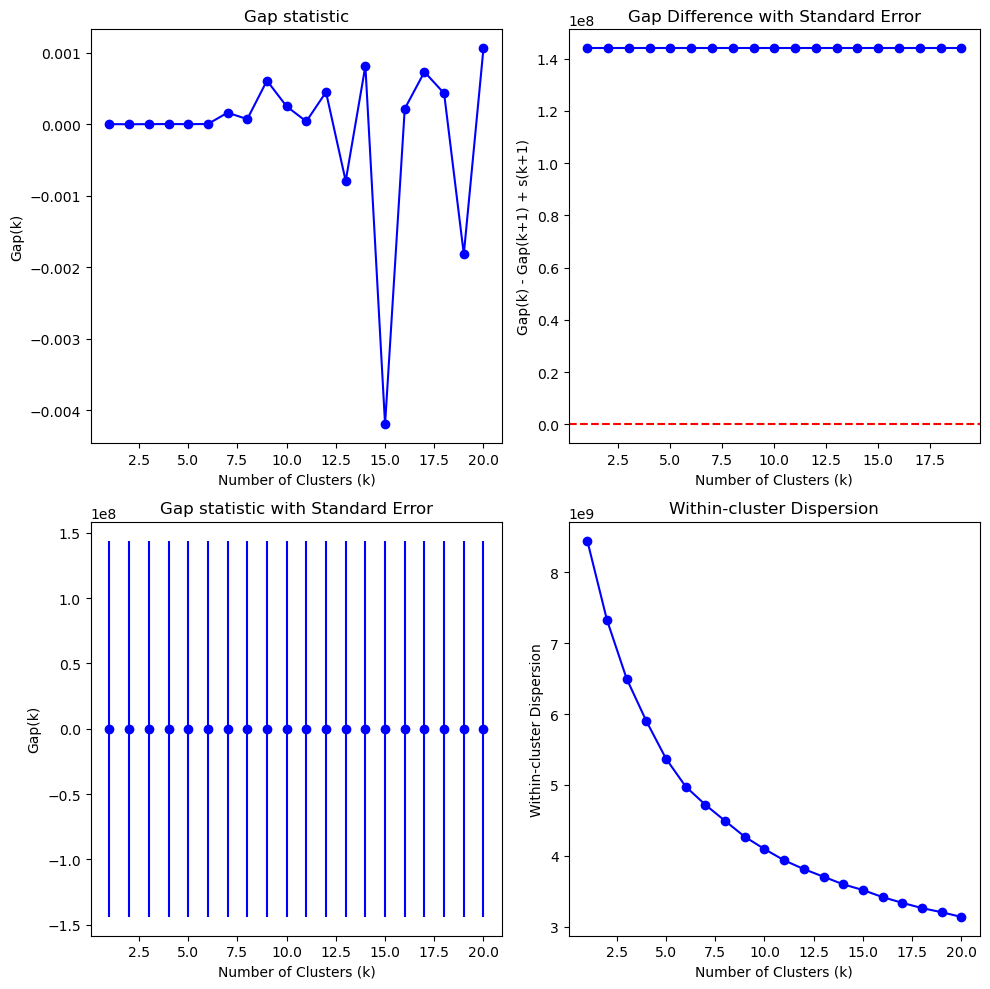

1

In [99]:
select_k_by_Gap_statistic(X, kmax=20, B=B, need_PCA=False, need_plot=True)

Note that now we obtain exactly the same results when using the two different reference distributions. Why?

When determining k using the Gap statistic, the outcomes are equivalent when the same data X is utilized for both situations (need_PCA=True and need_PCA=False) and the number of components (n_components) in PCA is fixed. This is due to the fact that the dimensionality of the data has already been reduced to the requested number of components (n_components=10 in this case) by the PCA transformation done by pca_complete_dataset.transform(digits_data).

If need_PCA=True, then the Gap statistic is computed using the PCA-transformed data X. Since X's dimensions have been cut in half (to 10), the Gap statistic can be computed in the new, more manageable setting.

In the second scenario (need_PCA=False), the Gap statistic is computed with the raw data. The original data points are already represented in the lower-dimensional space of X, however, due to the PCA transformation that has already been applied. Thus, the results of a Gap statistic computation using the raw data points are identical to those obtained by utilizing X directly.

### (d) Explore how the PCA projection dimension $d$ affect the $\hat k$ selected by the Gap statistic.

For each PCA projection dimension $d$ in `[1, 5, 10, 15, 20, 25, 40, 60]`, apply the Gap statistic and find the selected $\hat{k}$. Make a plot of $\hat{k}$ against $d$.

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

...

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

PCA with 60 components. Selected k: 1


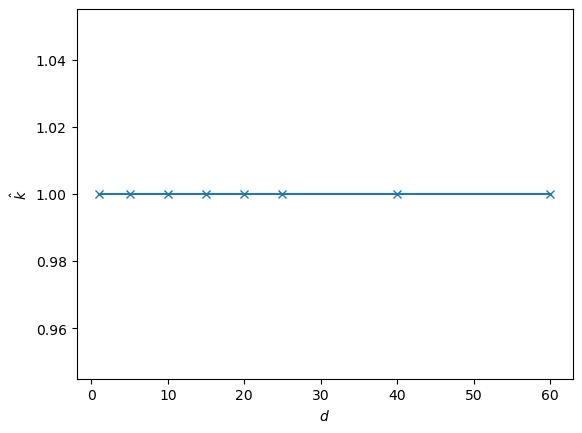

In [100]:
# example code. You may modify it.
d_list = [1, 5, 10, 15, 20, 25, 40, 60]
k_hat_list = []
for d in d_list:
    pca_complete_dataset = PCA(n_components=d)
    pca_complete_dataset.fit(digits_data)
    X = pca_complete_dataset.transform(digits_data[:1000, ]) # reduce the sample size for efficiency
    k_hat = select_k_by_Gap_statistic(X, kmax=20, B=50, need_PCA=False, need_plot=False)
    k_hat_list.append(k_hat)
    print(f"PCA with {d} components. Selected k: {k_hat}")

plt.plot(d_list, k_hat_list, 'x-')
plt.xlabel(r'$d$')
plt.ylabel(r'$\hat k$')
plt.show()

Intuitively explain why you see $\hat{k}$ change with $d$ in this way.

In the given code, PCA is executed with different component counts (d) and cluster counts (k) are determined by the Gap statistic. The dispersion inside a cluster, as measured by the Gap statistic, is quantified relative to what would be predicted from a null distribution.
The PCA transformation retains more components as d grows, allowing for a greater sum of variance to be captured. More nuanced data may be stored because to this improved variance representation. This suggests that an increase in the number of components may lead to an increase in the complexity or structure of the data by virtue of the presence of finer-grained patterns.
The fundamental structure of the data affects the connection between k and d. There may be more hidden groups or patterns in the data that are revealed by the PCA components as d grows. As a result, the Gap statistic can conclude that a larger optimum number of clusters (k) is needed to adequately capture the structure found by PCA. Since the PCA transformation captures more complexity and detail as d rises, the ideal k value may likewise rise.
The selected k value is plotted against d to show how it responds to change. The appropriate number of clusters is affected by the data's complexity and structure, which may be shown by examining the correlation between d and k.

### (e) Repeat (d) on the projection scores of your favorite digit. Again, make a plot of $\hat{k}$ against $d$.

Consider $d$ in `[2, 3, 5, 10, 15, 20, 25, 40]`.  Note that we use the PCA model *fitted on the entire data set*, but only use the projection scores of your favorite digit.

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

...

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/t0m/anaconda3/lib/pyt

PCA with 40 components. Selected k: 1


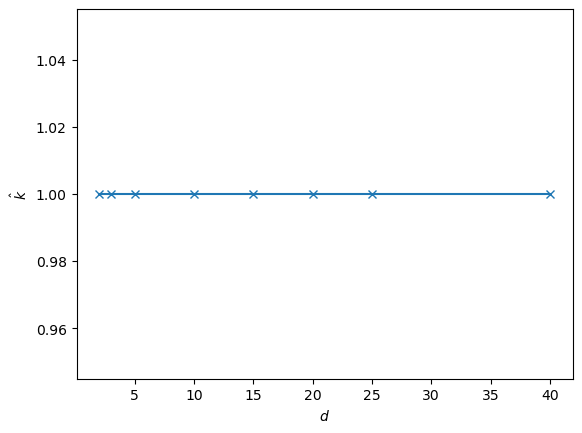

In [101]:
# example code. You may modify it.
d_list = [2, 3, 5, 10, 15, 20, 25, 40]
k_hat_list = []
for d in d_list:
    pca_complete_dataset = PCA(n_components=d)
    pca_complete_dataset.fit(digits_data)
    X = pca_complete_dataset.transform(digits_data[digits_target == num, ]) # reduce the sample size for efficiency
    k_hat = select_k_by_Gap_statistic(X, kmax=20, B=50, need_PCA=False, need_plot=False)
    k_hat_list.append(k_hat)
    print(f"PCA with {d} components. Selected k: {k_hat}")

plt.plot(d_list, k_hat_list, 'x-')
plt.xlabel(r'$d$')
plt.ylabel(r'$\hat k$')
plt.show()

Intuitively explain why you see $\hat{k}$ change with $d$ in this way.

The provided code executes principal component analysis (PCA) on a subset of the digits_data corresponding to a given goal value (num) using a range of component numbers (d). Then, it takes each PCA output and employs the Gap statistic to determine how many clusters to create (k).
When d is small, the PCA transformation only catches a fraction of the available data variation. The information remembered may be more generalized or less specific if fewer parts are stored. This means that the data's true structure or trends can be obscured.
When d grows larger, more components are kept, and thus more of the data's variance is accounted for. This more comprehensive representation has the potential to highlight more granular clusters or structure within the designated class (number).
How k and d are related depends on the nature of the data for the target class in question. It is possible that more clusters or finer distinctions within the target class will be discovered as d grows since more components gather more precise information. To better depict the complex structure found by PCA, the Gap statistic may thus find a larger ideal number of clusters (k).
The plot shows how the target class-specific k value varies as a function of d. The best number of clusters can be determined by analyzing the relationship between d and k, which reveals how the complexity and structure of the target class affects the decision.